# NB5.1 — Calibração de Câmara com Padrões de Xadrez

## Objetivos de Aprendizagem

Neste caderno, pretende-se que o estudante consiga:

1. **Compreender o modelo de câmara pinhole** e a relação entre coordenadas 3D do mundo e coordenadas 2D da imagem.
2. **Detectar cantos de um padrão de xadrez** em múltiplas poses usando OpenCV, quantificando as taxas de sucesso e falha.
3. **Estimar os parâmetros intrínsecos da câmara** — distância focal, ponto principal, e coeficientes de distorção — através de um pipeline de calibração não linear.
4. **Quantificar a qualidade da calibração** utilizando o erro de reprojeção (RMS) e identificar as causas prováveis de erros elevados.
5. **Aplicar a calibração aos seus próprios dados capturados** e diagnosticar deficiências de captura ou alinhamento de câmara.

Este caderno integra dados generalistas de exemplo para aprendizagem imediata, seguidos de um espaço claro para análise dos seus próprios dados.

**Competência alvo:** C5.1 — Calibrar uma câmara monocular utilizando um padrão planar, estimar os parâmetros intrínsecos com OpenCV, e quantificar a qualidade da calibração através do erro de reprojeção (RMS).

---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/ComputerVision/blob/main/NB5.1_camera_calibration.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```


In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Clona o repositório completo para garantir acesso aos dados/imagens.

from pathlib import Path
import os

repo_dir = Path("/content/ComputerVision")

if not repo_dir.exists():
    !git clone https://github.com/ppestana-supervisor/ComputerVision.git {repo_dir}

os.chdir(repo_dir)
print("Diretório atual:", os.getcwd())
print("Conteúdo:", os.listdir("."))

In [ ]:
!pip install -r requirements_colab.txt

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from glob import glob
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## Fase 1: Geração de Dados Sintéticos de Exemplo

Para garantir que possa começar imediatamente, este caderno gera um conjunto de imagens sintéticas de um padrão de xadrez de 10×7 quadrados (resultando em 9×6 cantos internos) capturado em várias poses. Estas imagens simulam uma câmara real com distorção radial e tangencial.

O padrão tem dimensões de 25 mm × 25 mm por quadrado. As poses variam em rotação e translação para criar um conjunto de calibração realista. Na prática, o estudante capturaria estas imagens com um padrão impresso físico e uma câmara real (algo que pediremos mais à frente).

In [2]:
def create_synthetic_checkerboard_images(num_images=15, pattern_size=(9, 6), square_size=25.0):
    images = []
    object_points_list = []
    
    width, height = 640, 480
    
    K_true = np.array([
        [600, 0, width / 2],
        [0, 600, height / 2],
        [0, 0, 1]
    ], dtype=np.float32)
    
    dist_true = np.array([0.1, -0.05, 0.001, 0.0005, -0.02], dtype=np.float32)
    
    cols, rows = pattern_size
    
    # Inner corner object points: what OpenCV will detect
    object_points = np.zeros((cols * rows, 3), dtype=np.float32)
    object_points[:, :2] = np.mgrid[0:cols, 0:rows].T.reshape(-1, 2)
    object_points *= square_size
    
    # Full board grid points, including outer border
    # For 9×6 inner corners, we need 10×7 squares = 11×8 grid vertices
    board_vertices = []
    for y in range(-1, rows + 1):
        for x in range(-1, cols + 1):
            board_vertices.append([x * square_size, y * square_size, 0])
    board_vertices = np.array(board_vertices, dtype=np.float32)
    
    grid_width = cols + 2   # vertices horizontally
    grid_height = rows + 2  # vertices vertically
    
    attempts = 0
    
    while len(images) < num_images and attempts < num_images * 20:
        attempts += 1
        
        angle_x = np.random.uniform(-25, 25)
        angle_y = np.random.uniform(-25, 25)
        angle_z = np.random.uniform(-15, 15)
        
        rvec = np.array([
            np.radians(angle_x),
            np.radians(angle_y),
            np.radians(angle_z)
        ], dtype=np.float32)
        
        tvec = np.array([
            np.random.uniform(-70, 70),
            np.random.uniform(-50, 50),
            450 + np.random.uniform(-70, 70)
        ], dtype=np.float32)
        
        # Project inner corners
        image_points_inner, _ = cv2.projectPoints(
            object_points, rvec, tvec, K_true, dist_true
        )
        corners_inner = image_points_inner.reshape(-1, 2)
        
        # Keep only fully visible boards
        in_bounds = np.sum(
            (corners_inner[:, 0] > 20) & (corners_inner[:, 0] < width - 20) &
            (corners_inner[:, 1] > 20) & (corners_inner[:, 1] < height - 20)
        )
        
        if in_bounds != len(object_points):
            continue
        
        # Project full board vertices
        image_points_board, _ = cv2.projectPoints(
            board_vertices, rvec, tvec, K_true, dist_true
        )
        corners_board = image_points_board.reshape(-1, 2)
        
        # Create image
        img = np.ones((height, width, 3), dtype=np.uint8) * 200
        
        # Draw 10×7 chessboard squares
        for y in range(rows + 1):
            for x in range(cols + 1):
                idx00 = y * grid_width + x
                idx10 = y * grid_width + (x + 1)
                idx11 = (y + 1) * grid_width + (x + 1)
                idx01 = (y + 1) * grid_width + x
                
                square = corners_board[[idx00, idx10, idx11, idx01]].astype(np.int32)
                
                color = (30, 30, 30) if (x + y) % 2 == 0 else (230, 230, 230)
                cv2.fillConvexPoly(img, square, color)
        
        images.append(img)
        object_points_list.append(object_points.copy())
    
    return images, object_points_list, K_true, dist_true


img_list, obj_points_list, K_true, dist_true = create_synthetic_checkerboard_images(num_images=12)

print(f"Generated {len(img_list)} synthetic calibration images.")

if len(img_list) > 0:
    print(f"Image size: {img_list[0].shape}")

print("True camera matrix K:")
print(K_true)

print("True distortion coefficients:")
print(dist_true)

Generated 12 synthetic calibration images.
Image size: (480, 640, 3)
True camera matrix K:
[[600.   0. 320.]
 [  0. 600. 240.]
 [  0.   0.   1.]]
True distortion coefficients:
[ 0.1    -0.05    0.001   0.0005 -0.02  ]


## Fase 2: Visualização e Carregamento de Imagens

Abaixo, carregamos o conjunto de imagens geradas (ou as suas próprias imagens de calibração, se as tiver). Exibimos as primeiras imagens para verificar a qualidade e confirmar que o padrão de xadrez é claramente visível.

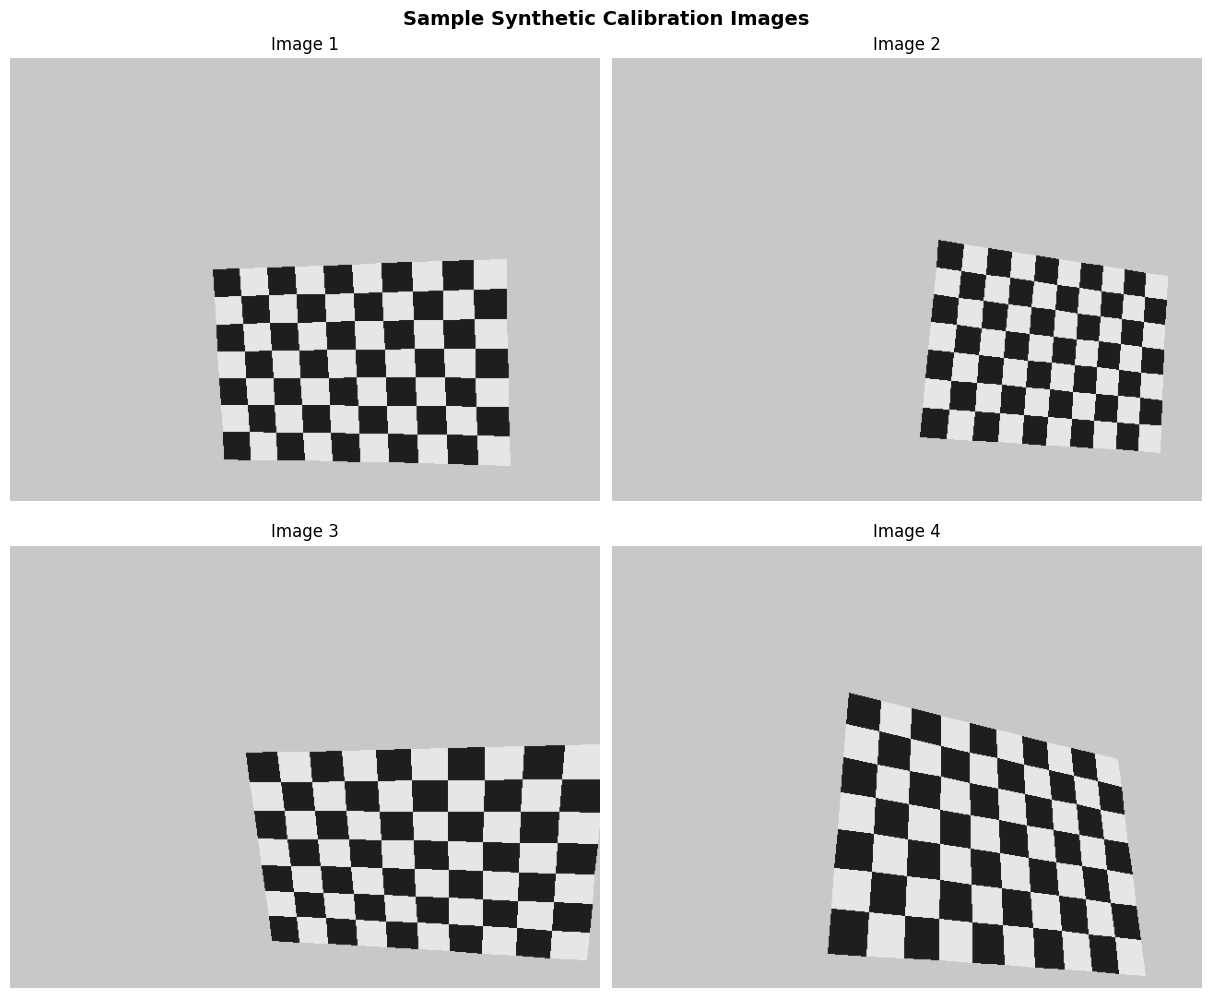

Loaded 12 images for calibration.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for idx, ax in enumerate(axes.flat):
    if idx < len(img_list):
        ax.imshow(cv2.cvtColor(img_list[idx], cv2.COLOR_BGR2RGB))
        ax.set_title(f'Image {idx + 1}')
    ax.axis('off')
plt.suptitle('Sample Synthetic Calibration Images', fontsize=14, fontweight='bold')
plt.show()

print(f"Loaded {len(img_list)} images for calibration.")

## Fase 3: Detecção de Cantos do Padrão de Xadrez

A função `cv2.findChessboardCorners()` detecta os cantos interiores do padrão de xadrez em cada imagem. Utiliza um algoritmo de refinamento de subespaço para atingir precisão sub-pixel. Sucesso significa que todos os 54 cantos (9 × 6) foram localizados.

Os cantos detectados serão depois ligados aos correspondentes pontos 3D no mundo, criando pares (ponto 3D, ponto 2D imagem) que alimentam o algoritmo de calibração.

In [4]:
def detect_chessboard_corners(images, pattern_size=(9, 6)):
    all_image_points = []
    image_points_per_image = []
    success_count = 0
    flags = (
        cv2.CALIB_CB_ADAPTIVE_THRESH +
        cv2.CALIB_CB_NORMALIZE_IMAGE
    )
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        ret, corners = cv2.findChessboardCorners(gray, pattern_size, flags)
        if ret:
            corners_refined = cv2.cornerSubPix(
                gray,
                corners,
                (11, 11),
                (-1, -1),
                criteria=(
                    cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
                    30,
                    0.001
                )
            )
            
            all_image_points.append(corners_refined)
            image_points_per_image.append(corners_refined.reshape(-1, 2))
            success_count += 1
        else:
            image_points_per_image.append(None)
    
    return all_image_points, success_count, image_points_per_image

detected_corners, success_count, corners_per_img = detect_chessboard_corners(img_list)
print("Corner detection results:")
print(f"  Successfully detected: {success_count} / {len(img_list)} images")
print(f"  Corners per image: {len(detected_corners[0]) if detected_corners else 0} expected 54")

Corner detection results:
  Successfully detected: 12 / 12 images
  Corners per image: 54 expected 54


## Fase 4: Visualização dos Cantos Detectados

Aqui, desenhamos os cantos detectados sobre a primeira imagem. Cantos em azul no plot indicam sucesso; a ausência de cantos indica que `cv2.findChessboardCorners()` falhou. Uma falha frequente sugere iluminação inadequada, foco deficiente, ou um padrão parcialmente visível na imagem.

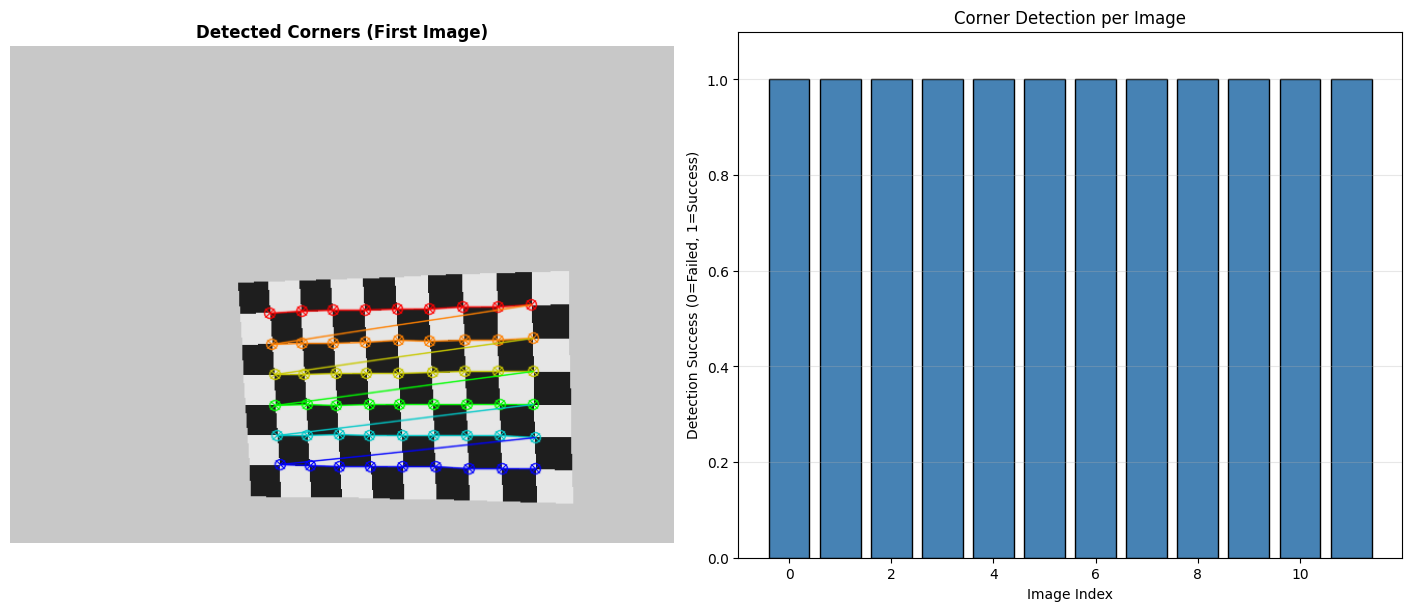

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if len(detected_corners) > 0:
    img_with_corners = cv2.drawChessboardCorners(img_list[0].copy(), (9, 6), detected_corners[0], True)
    axes[0].imshow(cv2.cvtColor(img_with_corners, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Detected Corners (First Image)', fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No corners detected', ha='center', va='center')
    axes[0].set_title('Detected Corners (First Image)', fontweight='bold')
axes[0].axis('off')

detection_counts = [1 if corners is not None else 0 for corners in corners_per_img]
axes[1].bar(range(len(detection_counts)), detection_counts, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Image Index')
axes[1].set_ylabel('Detection Success (0=Failed, 1=Success)')
axes[1].set_title('Corner Detection per Image')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)

plt.show()

## Fase 5: Calibração de Câmara com OpenCV

A função `cv2.calibrateCamera()` resolve o problema de calibração não linear. Minimiza o erro de reprojeção entre os pontos 3D projetados e os cantos 2D observados na imagem, ajustando simultaneamente os parâmetros intrínsecos (matriz K) e extrínsecos (rotação e translação de cada imagem).

Os parâmetros intrínsecos incluem:
- **fx, fy:** Distância focal em píxeis (horizontal e vertical)
- **cx, cy:** Coordenadas do ponto principal (centro de projeção)
- **k1, k2, p1, p2, k3, ...:** Coeficientes de distorção (radial e tangencial)

O valor de retorno é o erro RMS global: quanto menor, melhor a calibração.

In [6]:
def prepare_calibration_data(obj_points_list, detected_corners, pattern_size=(9, 6), square_size=25.0):
    objectPoints = []
    imagePoints = []
    
    world_pts = np.zeros((pattern_size[0] * pattern_size[1], 3), dtype=np.float32)
    world_pts[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
    world_pts *= square_size
    
    for corners in detected_corners:
        objectPoints.append(world_pts)
        imagePoints.append(corners.reshape(-1, 2))
    
    return objectPoints, imagePoints


objectPoints, imagePoints = prepare_calibration_data(obj_points_list, detected_corners)

image_size = (img_list[0].shape[1], img_list[0].shape[0])

rms_error, K, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    objectPoints, imagePoints, image_size,
    None, None,
    flags=cv2.CALIB_FIX_PRINCIPAL_POINT
)

print(f"Calibration Results:")
print(f"  RMS Reprojection Error: {rms_error:.4f} pixels")
print(f"  Image size: {image_size}")
print(f"\nIntrinsic Matrix K:")
print(f"  fx = {K[0, 0]:.2f}")
print(f"  fy = {K[1, 1]:.2f}")
print(f"  cx = {K[0, 2]:.2f}")
print(f"  cy = {K[1, 2]:.2f}")
print(f"\nDistortion Coefficients:")
print(f"  k1, k2 (radial):  {dist_coeffs[0, 0]:.6f}, {dist_coeffs[0, 1]:.6f}")
print(f"  p1, p2 (tangential): {dist_coeffs[0, 2]:.6f}, {dist_coeffs[0, 3]:.6f}")
if len(dist_coeffs[0]) > 4:
    print(f"  k3 (radial):      {dist_coeffs[0, 4]:.6f}")

Calibration Results:
  RMS Reprojection Error: 0.4157 pixels
  Image size: (640, 480)

Intrinsic Matrix K:
  fx = 599.11
  fy = 599.16
  cx = 319.50
  cy = 239.50

Distortion Coefficients:
  k1, k2 (radial):  0.118941, -0.185305
  p1, p2 (tangential): 0.001221, 0.000588
  k3 (radial):      0.290902


## Fase 6: Verificação de Reprojeção

Reprojetamos os pontos 3D do mundo de volta para a imagem utilizando a matriz K calibrada e os coeficientes de distorção. Comparamos estes pontos reprojetados com os cantos detectados originalmente. Uma sobreposição próxima (erro < 0.5 píxeis) indica uma calibração de alta qualidade.

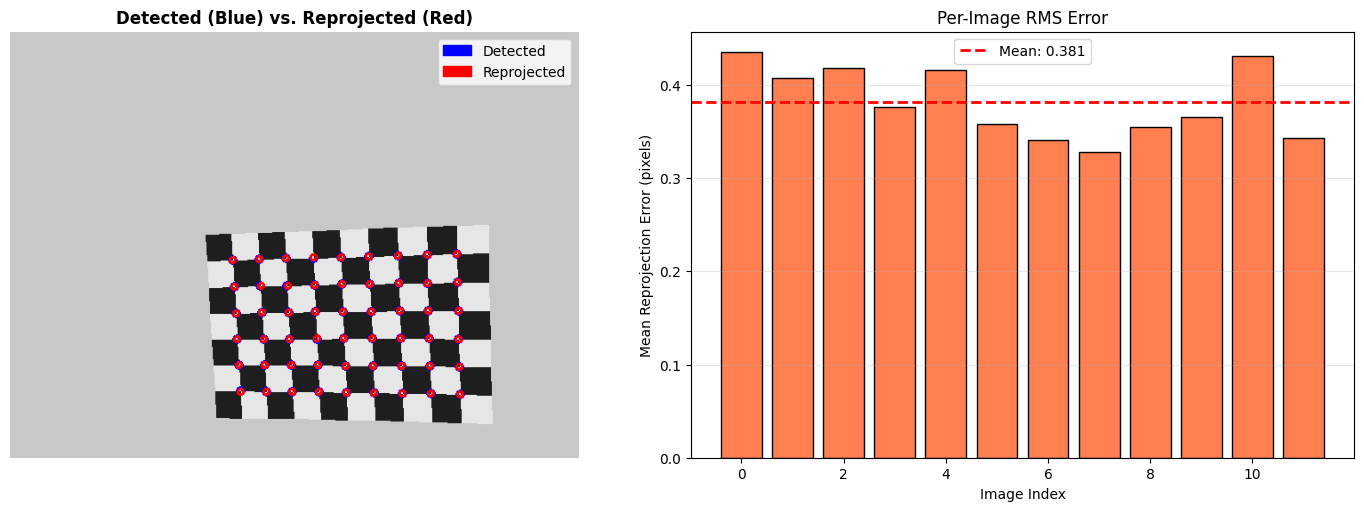

Reprojection Error Analysis:
  Per-image RMS (pixels): min=0.3284, max=0.4353, mean=0.3812


In [7]:
def compute_reprojection_errors(objectPoints, imagePoints, K, dist_coeffs, rvecs, tvecs):
    mean_errors = []
    
    for i in range(len(objectPoints)):
        projected_points, _ = cv2.projectPoints(objectPoints[i], rvecs[i], tvecs[i], K, dist_coeffs)
        projected_points = projected_points.reshape(-1, 2)
        observed = imagePoints[i]
        
        errors = np.linalg.norm(projected_points - observed, axis=1)
        mean_errors.append(errors)
    
    return mean_errors


reprojection_errors = compute_reprojection_errors(objectPoints, imagePoints, K, dist_coeffs, rvecs, tvecs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(detected_corners) > 0:
    img_repr = img_list[0].copy()
    
    # Draw detected corners in blue
    for corner in imagePoints[0].astype(int):
        cv2.circle(img_repr, tuple(corner), 4, (255, 0, 0), 2)
    
    # Project and draw reprojected corners in red
    reprojected, _ = cv2.projectPoints(objectPoints[0], rvecs[0], tvecs[0], K, dist_coeffs)
    reprojected = reprojected.reshape(-1, 2).astype(int)
    for corner in reprojected:
        cv2.circle(img_repr, tuple(corner), 3, (0, 0, 255), 2)
    
    axes[0].imshow(cv2.cvtColor(img_repr, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Detected (Blue) vs. Reprojected (Red)', fontweight='bold')
    axes[0].axis('off')
    
    blue_patch = mpatches.Patch(color=(0, 0, 1), label='Detected')
    red_patch = mpatches.Patch(color=(1, 0, 0), label='Reprojected')
    axes[0].legend(handles=[blue_patch, red_patch], loc='upper right')

# Plot RMS errors per image
rms_per_image = [np.mean(err) for err in reprojection_errors]
axes[1].bar(range(len(rms_per_image)), rms_per_image, color='coral', edgecolor='black')
axes[1].axhline(y=np.mean(rms_per_image), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(rms_per_image):.3f}')
axes[1].set_xlabel('Image Index')
axes[1].set_ylabel('Mean Reprojection Error (pixels)')
axes[1].set_title('Per-Image RMS Error')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.show()

print(f"Reprojection Error Analysis:")
print(f"  Per-image RMS (pixels): min={np.min(rms_per_image):.4f}, max={np.max(rms_per_image):.4f}, mean={np.mean(rms_per_image):.4f}")

## Fase 7: Transição para os seus Próprios Dados

Para a parte com dados reais, imprima um padrão de xadrez com 10×7 quadrados, correspondente a 9×6 cantos interiores. Cole-o numa superfície plana e fotografe-o em pelo menos 15–20 poses distintas. A próxima célula gera esse padrão (em Colab, do lado esquerdo ir a files, e procurar o ficheiro dentro de Calibratio_pattern). Na célula seguinte, defina o caminho para a pasta que contém as suas fotografias. As imagens devem conter por inteiro o padrão de xadrez 9×6 capturado em várias poses.


In [8]:
cols_squares = 10
rows_squares = 7
square_size_mm = 20
out_dir = Path("calibration_pattern")
out_dir.mkdir(exist_ok=True)
pattern = np.indices((rows_squares, cols_squares)).sum(axis=0) % 2
fig_w_in = (cols_squares * square_size_mm) / 25.4
fig_h_in = (rows_squares * square_size_mm) / 25.4
fig, ax = plt.subplots(figsize=(fig_w_in, fig_h_in), dpi=300)
ax.imshow(pattern, cmap="gray", interpolation="nearest", vmin=0, vmax=1)
ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
png_path = out_dir / "checkerboard_9x6_inner_corners_20mm.png"
pdf_path = out_dir / "checkerboard_9x6_inner_corners_20mm.pdf"

fig.savefig(png_path, dpi=300, bbox_inches="tight", pad_inches=0)
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0)
plt.close(fig)

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")
print("Print at 100% / Actual size.")
print("Board size:", cols_squares * square_size_mm, "mm ×", rows_squares * square_size_mm, "mm")
print("Square size:", square_size_mm, "mm")

Saved: calibration_pattern/checkerboard_9x6_inner_corners_20mm.png
Saved: calibration_pattern/checkerboard_9x6_inner_corners_20mm.pdf
Print at 100% / Actual size.
Board size: 200 mm × 140 mm
Square size: 20 mm


In [14]:
# Path to your own calibration images (edit if necessary)
user_data_path = Path("./my_calibration_images")

if user_data_path.exists():
    user_images_paths = sorted(glob(str(user_data_path / "*.jpg"))) + sorted(glob(str(user_data_path / "*.png")))
    user_img_list = [cv2.imread(path) for path in user_images_paths]
    user_img_list = [img for img in user_img_list if img is not None]
    print(f"Loaded {len(user_img_list)} images from {user_data_path}")
    if len(user_img_list) > 0:
        print(f"Image size: {user_img_list[0].shape}")
else:
    print(f"Path {user_data_path} not found. Continuing with synthetic data.")
    user_img_list = None

Loaded 14 images from my_calibration_images
Image size: (480, 640, 3)


## Fase 8: Calibração com Dados do Utilizador

Se carregou imagens dos seus próprios dados, execute este bloco para calibrar a sua câmara. Os parâmetros intrínsecos resultantes serão específicos do seu hardware.

In [ ]:
if user_img_list is not None and len(user_img_list) > 3:
    user_detected_corners, user_success, _ = detect_chessboard_corners(user_img_list)
    
    if len(user_detected_corners) > 3:
        user_objectPoints, user_imagePoints = prepare_calibration_data(None, user_detected_corners)
        user_image_size = (user_img_list[0].shape[1], user_img_list[0].shape[0])
        
        user_rms, user_K, user_dist, user_rvecs, user_tvecs = cv2.calibrateCamera(
            user_objectPoints,
            user_imagePoints,
            user_image_size,
            None,
            None,
            flags=0
        )
        
        print("User Data Calibration Results:")
        print(f"  RMS Reprojection Error: {user_rms:.4f} pixels")
        print(f"  Images successfully detected: {len(user_detected_corners)} / {len(user_img_list)}")
        print("\nIntrinsic Matrix K:")
        print(user_K)
        print("\nDistortion Coefficients:")
        print(user_dist[0])

        calib_dir = Path("correspondencia/calibration")
        calib_dir.mkdir(parents=True, exist_ok=True)

        user_calib_path = calib_dir / "user_camera_calibration.npz"

        np.savez(
            user_calib_path,
            K=user_K,
            dist_coeffs=user_dist,
            rms=user_rms,
            image_size=np.array(user_image_size),
            num_images=len(user_img_list),
            num_detections=len(user_detected_corners)
        )

        print(f"\nCalibração guardada em: {user_calib_path}")

    else:
        print(f"Could not detect corners in enough images. Got {len(user_detected_corners)} detections.")
else:
    print("No user images loaded or insufficient number of images for calibration.")

User Data Calibration Results:
  RMS Reprojection Error: 0.3331 pixels
  Images successfully detected: 13 / 14

Intrinsic Matrix K:
[[526.87093544   0.         316.53329795]
 [  0.         524.90556542 231.60597002]
 [  0.           0.           1.        ]]

Distortion Coefficients:
[ 3.61766144e-01 -2.52355985e+00 -7.72927561e-03 -1.74595788e-03
  6.36586355e+00]

Calibração guardada em: correspondencia/calibration/user_camera_calibration.npz


## Fase 9: Análise de Erro RMS por Imagem

O erro RMS varia por imagem. Imagens com RMS elevado podem indicar:
- Iluminação deficiente ou não uniforme
- Desfoque ou movimento durante a captura
- Padrão parcialmente visível ou ocluído
- Pose extrema (muito inclinada ou perto da câmara)

Visualizamos um histograma dos erros por imagem e destacamos outliers (> média + 1.5 × desvio padrão).

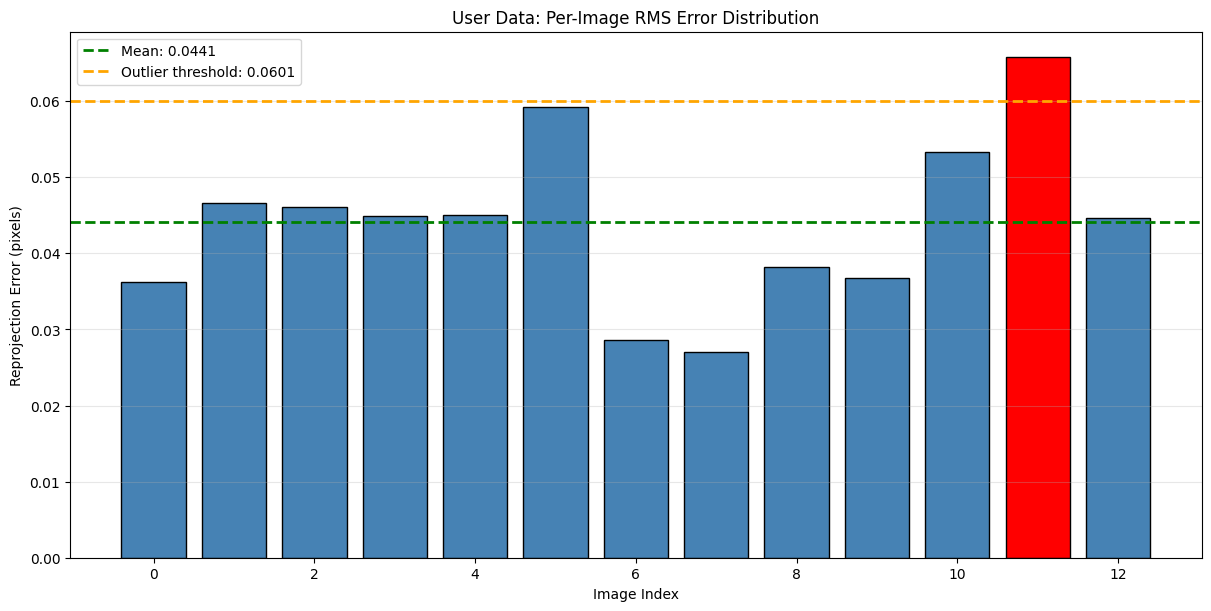

In [25]:
user_reprojection_errors = []

for i in range(len(user_objectPoints)):
    imgpoints2, _ = cv2.projectPoints(user_objectPoints[i], user_rvecs[i], user_tvecs[i], user_K, user_dist)
    
    p1 = user_imagePoints[i].reshape(-1, 2).astype(np.float32)
    p2 = imgpoints2.reshape(-1, 2).astype(np.float32)
    
    total_error = cv2.norm(p1, p2, cv2.NORM_L2)
    user_reprojection_errors.append(total_error / len(p2))

rms_per_image_user = np.array(user_reprojection_errors)
mean_rms = np.mean(rms_per_image_user)
std_rms = np.std(rms_per_image_user)
threshold = mean_rms + 1.5 * std_rms

outlier_indices = np.where(rms_per_image_user > threshold)[0]

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['red' if i in outlier_indices else 'steelblue' for i in range(len(rms_per_image_user))]

ax.bar(range(len(rms_per_image_user)), rms_per_image_user, color=colors, edgecolor='black')
ax.axhline(y=mean_rms, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_rms:.4f}')
ax.axhline(y=threshold, color='orange', linestyle='--', linewidth=2, label=f'Outlier threshold: {threshold:.4f}')

ax.set_xlabel('Image Index')
ax.set_ylabel('Reprojection Error (pixels)')
ax.set_title('User Data: Per-Image RMS Error Distribution')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.show()

## Fase 10: Inspeção Detalhada de Imagem Problemática

Se existe uma imagem com erro RMS significativamente mais elevado, inspecionamos visualmente os cantos detectados vs. reprojetados nessa imagem. Desalinhamentos grandes indicam que a detecção de cantos falhou ou a pose é patológica. Se lhe parecer que a imagem tem problemas evidentes (blur, canto cortado) elimine-a e corra as células anteriores, caso contrário considere o processo de calibração fechado.

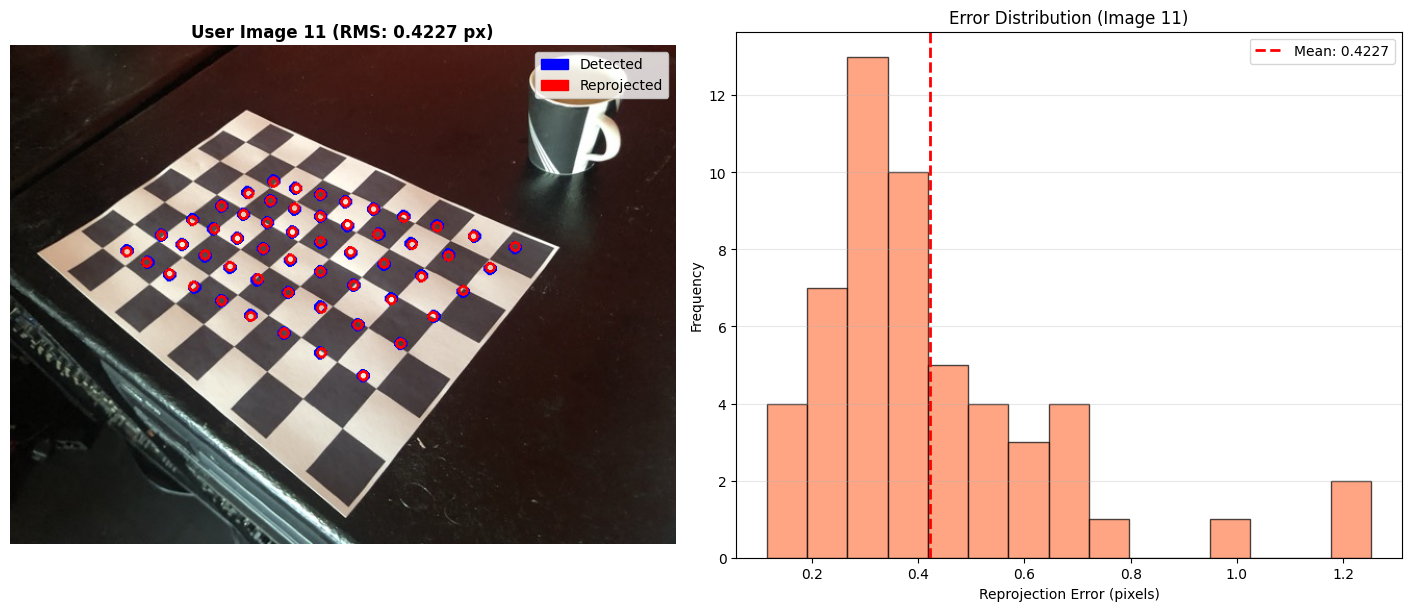

In [26]:
import matplotlib.patches as mpatches

user_reprojection_errors_all_points = []

for i in range(len(user_objectPoints)):
    imgpoints2, _ = cv2.projectPoints(
        user_objectPoints[i], user_rvecs[i], user_tvecs[i], user_K, user_dist
    )
    
    p1 = user_imagePoints[i].reshape(-1, 2).astype(np.float32)
    p2 = imgpoints2.reshape(-1, 2).astype(np.float32)
    
    dists = np.linalg.norm(p1 - p2, axis=1)
    user_reprojection_errors_all_points.append(dists)

rms_per_image_user = np.array([np.mean(d) for d in user_reprojection_errors_all_points])
if len(outlier_indices) > 0:
    worst_idx = outlier_indices[0] 
else:
    worst_idx = np.argmax(rms_per_image_user)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

img_worst = user_img_list[worst_idx].copy()

for corner in user_imagePoints[worst_idx].reshape(-1, 2).astype(int):
    cv2.circle(img_worst, tuple(corner), 5, (255, 0, 0), 2)

reprojected_worst, _ = cv2.projectPoints(
    user_objectPoints[worst_idx], user_rvecs[worst_idx], user_tvecs[worst_idx], user_K, user_dist
)
reprojected_worst = reprojected_worst.reshape(-1, 2).astype(int)
for corner in reprojected_worst:
    cv2.circle(img_worst, tuple(corner), 4, (0, 0, 255), 2)

axes[0].imshow(cv2.cvtColor(img_worst, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'User Image {worst_idx} (RMS: {rms_per_image_user[worst_idx]:.4f} px)', fontweight='bold')
axes[0].axis('off')

blue_patch = mpatches.Patch(color=(0, 0, 1), label='Detected')
red_patch = mpatches.Patch(color=(1, 0, 0), label='Reprojected')
axes[0].legend(handles=[blue_patch, red_patch], loc='upper right')

errors_worst = user_reprojection_errors_all_points[worst_idx]
axes[1].hist(errors_worst, bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(x=np.mean(errors_worst), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(errors_worst):.4f}')
axes[1].set_xlabel('Reprojection Error (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Error Distribution (Image {worst_idx})')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.show()

## Fase 11: Reflexão e Diagnóstico

Reflicta sobre estas questões para consolidar a sua compreensão:

### Questões de Reflexão

1. **Qualidade de Calibração**
   - O valor RMS global é inferior a 0.5 píxeis? Se não, qual é a causa provável? (Iluminação deficiente? Padrão mal alinhado? Câmara desfocada?)

2. **Imagem Problemática**
   - Qual é a imagem com maior erro RMS? O que observa na sobreposição dos cantos detectados vs. reprojetados?
   - Os erros são aleatórios ou concentram-se numa região específica da imagem?

3. **Protocolo de Captura**
   - Se fosse capturar novamente, como modificaria o protocolo para melhorar o resultado?
   - Quantas poses diferentes são realmente necessárias para obter uma boa calibração? (Resposta típica: ≥20 para robustez.)

4. **Parâmetros Calibrados**
   - A distância focal (fx, fy) é razoável dado o tamanho do sensor? (Para uma câmara típica, fx ≈ 500–800 para imagens de 640×480.)
   - Os coeficientes de distorção k1 e k2 têm sinais opostos? (Comum: k1 positivo, k2 negativo.)

**Não é necessário escrever respostas; reflita internamente e valide a sua compreensão.**

---

## Resumo

Concluiu o caderno de calibração de câmara. Aprendeu a:

1. Detectar cantos de um padrão de xadrez em múltiplas imagens.
2. Executar um pipeline de calibração não linear com OpenCV.
3. Quantificar a qualidade da calibração através do erro de reprojeção RMS.
4. Diagnosticar imagens problemáticas e compreender as causas de erros elevados.
5. Aplicar o mesmo pipeline aos seus próprios dados capturados.

**Próximos passos:**
- Se não o fez até agora, capture o seu próprio conjunto de calibração (≥20 imagens, variadas em pose).
- Calibre a sua câmara e guarde a matriz K e os coeficientes de distorção para uso em geometria epipolar e reconstução 3D (Semana 1 e 2).
- Capture um conjunto de imagens multi-vista de um objeto texturado para Structure from Motion (Semana 2).

**Documentação e referências:**
- OpenCV Camera Calibration: https://docs.opencv.org/master/d9/d0c/group__calib3d.html
- Hartley & Zisserman, *Multiple View Geometry in Computer Vision*, Capítulo 6.